# HateBERT PCL Detection — LoRA Adapter (PEFT)

This notebook fine-tunes `GroNLP/hateBERT` for SemEval Task 4 Subtask 1 using **LoRA adapters** (via the `peft` library) instead of full fine-tuning:

- Base model weights are **frozen**; only the low-rank adapter matrices are trained.
- LoRA is applied to the Q and V attention projections (`r=16`, `alpha=32`).
- The classification head is kept fully trainable via `modules_to_save`.
- Adapter training is significantly cheaper in memory and compute, allowing 5 epochs.
- Evaluation focuses on **macro F1** (`f1_macro`).

In [1]:
!pip install contractions python-dotenv huggingface_hub peft

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 557.0/557.0 kB 11.4 MB/s eta 0:00:00a 0:00:01


In [2]:
import os
import re
import random

import numpy as np
import pandas as pd
import torch

from sklearn.metrics import (
    f1_score,
    precision_score,
    recall_score,
    classification_report,
    confusion_matrix,
)

import matplotlib.pyplot as plt
import seaborn as sns
import contractions

from dotenv import load_dotenv
from huggingface_hub import login

from datasets import Dataset
from transformers import (
    AutoTokenizer,
    AutoModelForSequenceClassification,
    DataCollatorWithPadding,
    Trainer,
    TrainingArguments,
    set_seed,
)
from peft import (
    get_peft_model,
    LoraConfig,
    TaskType,
    PeftModel,
)

SEED = 42
set_seed(SEED)
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Using device: {device}')

/home/wowthecoder/imperial-nlp-cw/venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Using device: cuda


In [3]:
# Local auth: load Hugging Face token from .env
load_dotenv()
hf_token = os.getenv('HF_TOKEN')
if hf_token:
    login(token=hf_token)
    print('HF token loaded from .env and login completed.')
else:
    print('HF_TOKEN not found in .env; proceeding without explicit login.')

Note: Environment variable`HF_TOKEN` is set and is the current active token independently from the token you've just configured.


HF token loaded from .env and login completed.


In [4]:
# ============================================================
# Configuration
# ============================================================
MODEL_NAME  = 'GroNLP/hateBERT'
RUN_NAME    = 'checkpoints/hatebert_adapter'
MAX_LENGTH  = 256
NUM_EPOCHS  = 5   # adapter training is cheaper — more epochs at low cost

# LoRA hyperparameters
LORA_R          = 16
LORA_ALPHA      = 32
LORA_DROPOUT    = 0.1
# Q and V projections in every BERT self-attention layer
LORA_TARGET_MODULES = ['query', 'value']

DATA_ROOT      = '..'
TSV_PATH       = os.path.join(DATA_ROOT, 'dontpatronizeme_pcl.tsv')
TRAIN_IDS_PATH = os.path.join(DATA_ROOT, 'train', 'train_semeval_parids-labels.csv')
DEV_IDS_PATH   = os.path.join(DATA_ROOT, 'train', 'dev_semeval_parids-labels.csv')
TEST_PATH      = os.path.join(DATA_ROOT, 'test', 'task4_test.tsv')

os.makedirs(RUN_NAME, exist_ok=True)
print(f'RUN_NAME : {RUN_NAME}')

RUN_NAME : checkpoints/hatebert_adapter


In [5]:
def load_task1(train_path: str) -> pd.DataFrame:
    """
    Load Task 1 data and convert original labels to binary:
      0/1 -> 0 (No-PCL)
      2/3/4 -> 1 (PCL)
    """
    rows = []
    with open(train_path, encoding='utf-8') as f:
        for line in f.readlines()[4:]:
            parts = line.rstrip('\n').split('\t')
            if len(parts) < 6:
                continue

            par_id    = parts[0]
            art_id    = parts[1]
            keyword   = parts[2]
            country   = parts[3]
            text      = parts[4]
            orig_label = parts[-1]
            label     = 0 if orig_label in {'0', '1'} else 1

            rows.append(
                {
                    'par_id': str(par_id),
                    'art_id': art_id,
                    'keyword': keyword,
                    'country': country,
                    'text': text,
                    'label': label,
                    'orig_label': orig_label,
                }
            )

    return pd.DataFrame(
        rows,
        columns=['par_id', 'art_id', 'keyword', 'country', 'text', 'label', 'orig_label'],
    )

In [6]:
# ============================================================
# Load + preprocess data
# ============================================================
df = load_task1(TSV_PATH)


def preprocess_text(text: str) -> str:
    text = str(text)
    text = contractions.fix(text)
    text = re.sub(r'<[^>]+>', ' ', text)
    text = re.sub(r'\s+', ' ', text).strip()
    return text


df['clean_text'] = df['text'].apply(preprocess_text)

# Include keyword and country in model input text
df['keyword'] = df['keyword'].fillna('').astype(str)
df['country'] = df['country'].fillna('').astype(str)
df['model_text'] = (
    df['keyword'].str.strip() + ' </s> '
    + df['country'].str.strip() + ' </s> '
    + df['clean_text'].str.strip()
)

print(f'Loaded dataset: {len(df):,} samples')
print(df['label'].value_counts().sort_index().rename({0: 'No-PCL', 1: 'PCL'}))

Loaded dataset: 10,469 samples
label
No-PCL    9476
PCL        993
Name: count, dtype: int64


In [7]:
# ============================================================
# Official Train/Dev split + hard oversampling (8x positives)
# ============================================================
train_ids_df = pd.read_csv(TRAIN_IDS_PATH, dtype={'par_id': str})
dev_ids_df   = pd.read_csv(DEV_IDS_PATH,   dtype={'par_id': str})

train_par_ids = set(train_ids_df['par_id'].astype(str))
dev_par_ids   = set(dev_ids_df['par_id'].astype(str))

train_df   = df[df['par_id'].isin(train_par_ids)].copy().reset_index(drop=True)
dev_df     = df[df['par_id'].isin(dev_par_ids)].copy().reset_index(drop=True)
leftover_df = df[~df['par_id'].isin(train_par_ids | dev_par_ids)].copy().reset_index(drop=True)

if len(leftover_df) > 0:
    train_df = pd.concat([train_df, leftover_df], ignore_index=True)
    print(f'Appended {len(leftover_df):,} unassigned samples to training set.')


def describe_split(name: str, frame: pd.DataFrame):
    n       = len(frame)
    n_pcl   = int((frame['label'] == 1).sum())
    n_no    = int((frame['label'] == 0).sum())
    ratio   = f'1:{(n_no / n_pcl):.1f}' if n_pcl > 0 else 'undefined'
    print(f'{name:<20} -> total={n:,} | PCL={n_pcl:,} | No-PCL={n_no:,} | ratio={ratio}')


describe_split('Train (before OS)', train_df)
describe_split('Dev', dev_df)

replicated_pcls = pd.concat([train_df[train_df['label'] == 1]] * 8, ignore_index=True)
train_df = pd.concat([train_df, replicated_pcls], ignore_index=True)
train_df = train_df.sample(frac=1, random_state=SEED).reset_index(drop=True)

describe_split('Train (after OS)', train_df)

Train (before OS)    -> total=8,375 | PCL=794 | No-PCL=7,581 | ratio=1:9.5
Dev                  -> total=2,094 | PCL=199 | No-PCL=1,895 | ratio=1:9.5
Train (after OS)     -> total=14,727 | PCL=7,146 | No-PCL=7,581 | ratio=1:1.1


In [8]:
# ============================================================
# Tokenization + Hugging Face Datasets
# ============================================================
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)

train_hf = Dataset.from_pandas(
    train_df[['model_text', 'label']].rename(columns={'model_text': 'text'}),
    preserve_index=False,
)
dev_hf = Dataset.from_pandas(
    dev_df[['model_text', 'label']].rename(columns={'model_text': 'text'}),
    preserve_index=False,
)


def tokenize(batch):
    return tokenizer(batch['text'], truncation=True, max_length=MAX_LENGTH)


train_ds = train_hf.map(tokenize, batched=True, remove_columns=['text'])
dev_ds   = dev_hf.map(tokenize,   batched=True, remove_columns=['text'])

train_ds = train_ds.rename_column('label', 'labels')
dev_ds   = dev_ds.rename_column('label', 'labels')

train_ds.set_format(type='torch', columns=['input_ids', 'attention_mask', 'labels'])
dev_ds.set_format(type='torch',   columns=['input_ids', 'attention_mask', 'labels'])

data_collator = DataCollatorWithPadding(tokenizer=tokenizer)

print(train_ds)
print(dev_ds)

Map: 100%|██████████| 2094/2094 [00:00<00:00, 21238.16 examples/s]

Dataset({
    features: ['labels', 'input_ids', 'token_type_ids', 'attention_mask'],
    num_rows: 14727
})
Dataset({
    features: ['labels', 'input_ids', 'token_type_ids', 'attention_mask'],
    num_rows: 2094
})


In [9]:
# ============================================================
# Metrics (macro-F1 focused)
# ============================================================
def compute_metrics(eval_pred):
    logits, labels = eval_pred
    preds = np.argmax(logits, axis=-1)

    return {
        'f1_macro':        f1_score(labels, preds, average='macro',  zero_division=0),
        'precision_macro': precision_score(labels, preds, average='macro', zero_division=0),
        'recall_macro':    recall_score(labels, preds, average='macro', zero_division=0),
    }

In [10]:
# ============================================================
# Base model + LoRA adapter setup
# ============================================================
base_model = AutoModelForSequenceClassification.from_pretrained(
    MODEL_NAME,
    num_labels=2,
)

lora_config = LoraConfig(
    task_type=TaskType.SEQ_CLS,
    r=LORA_R,
    lora_alpha=LORA_ALPHA,
    target_modules=LORA_TARGET_MODULES,   # Q and V in every attention layer
    lora_dropout=LORA_DROPOUT,
    bias='none',
    # Keep the classifier head fully trainable (randomly initialised for new task)
    modules_to_save=['classifier'],
)

model = get_peft_model(base_model, lora_config)

# Report trainable vs. frozen parameter counts
trainable, total = model.get_nb_trainable_parameters()
print(f'Trainable params : {trainable:,}  ({100 * trainable / total:.2f}% of {total:,} total)')
model.print_trainable_parameters()

Loading weights: 100%|██████████| 199/199 [00:00<00:00, 368.46it/s, Materializing param=bert.pooler.dense.weight]                               
BertForSequenceClassification LOAD REPORT from: GroNLP/hateBERT
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.bias                       | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
classifier.bias                            | MISSING    | 
classifier.weight                          | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Trainable params : 591,362  (0.54% of 110,075,140 total)
trainable params: 591,362 || all params: 110,075,140 || trainable%: 0.5372


In [11]:
# ============================================================
# TrainingArguments + Trainer
# ============================================================
# With LoRA, the effective learning rate can be higher than full fine-tuning
# because only the adapter and classifier parameters are updated.
training_args = TrainingArguments(
    output_dir=RUN_NAME,
    num_train_epochs=NUM_EPOCHS,
    save_total_limit=2,
    learning_rate=3e-4,          # higher LR suits adapter-only training
    eval_strategy='epoch',
    save_strategy='epoch',
    load_best_model_at_end=True,
    metric_for_best_model='f1_macro',
    greater_is_better=True,
    per_device_train_batch_size=4,
    per_device_eval_batch_size=4,
    gradient_accumulation_steps=1,
    warmup_steps=500,
    lr_scheduler_type='cosine',
    adam_epsilon=1e-6,
    weight_decay=0.01,
    report_to='none',
    seed=SEED,
)

trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=train_ds,
    eval_dataset=dev_ds,
    processing_class=tokenizer,
    data_collator=data_collator,
    compute_metrics=compute_metrics,
)

print('Trainer configured.')

Trainer configured.


In [12]:
train_result = trainer.train()
train_result

Epoch,Training Loss,Validation Loss,F1 Macro,Precision Macro,Recall Macro
1,0.350253,0.429868,0.723481,0.687700,0.802430
2,0.192873,0.516895,0.731874,0.705673,0.771980
3,0.117316,0.733859,0.717056,0.684777,0.780999
4,0.048746,0.688371,0.740208,0.728104,0.754368
5,0.024313,0.723252,0.742995,0.733693,0.753439


TrainOutput(global_step=18410, training_loss=0.18125412027710225, metrics={'train_runtime': 1099.5737, 'train_samples_per_second': 66.967, 'train_steps_per_second': 16.743, 'total_flos': 3978490968889584.0, 'train_loss': 0.18125412027710225, 'epoch': 5.0})

In [13]:
eval_metrics = trainer.evaluate()
print('Evaluation metrics (best checkpoint):')
for k, v in eval_metrics.items():
    if isinstance(v, (int, float)):
        print(f'  {k}: {v:.4f}')
    else:
        print(f'  {k}: {v}')

Evaluation metrics (best checkpoint):
  eval_loss: 0.7233
  eval_f1_macro: 0.7430
  eval_precision_macro: 0.7337
  eval_recall_macro: 0.7534
  eval_runtime: 8.7938
  eval_samples_per_second: 238.1230
  eval_steps_per_second: 59.5880
  epoch: 5.0000


              precision    recall  f1-score   support

      No-PCL     0.9536    0.9441    0.9488      1895
         PCL     0.5138    0.5628    0.5372       199

    accuracy                         0.9078      2094
   macro avg     0.7337    0.7534    0.7430      2094
weighted avg     0.9118    0.9078    0.9097      2094



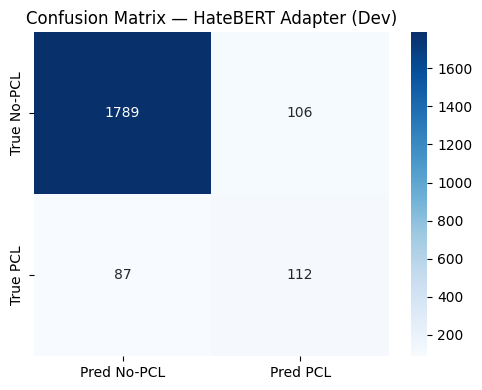

In [14]:
# ============================================================
# Detailed evaluation report + confusion matrix
# ============================================================
pred_output = trainer.predict(dev_ds)
logits  = pred_output.predictions
y_true  = pred_output.label_ids
y_pred  = np.argmax(logits, axis=-1)

print(classification_report(y_true, y_pred, target_names=['No-PCL', 'PCL'], digits=4, zero_division=0))

cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(5, 4))
sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=['Pred No-PCL', 'Pred PCL'],
    yticklabels=['True No-PCL', 'True PCL'],
)
plt.title('Confusion Matrix — HateBERT Adapter (Dev)')
plt.tight_layout()
plt.savefig(os.path.join(RUN_NAME, 'confusion_matrix.png'), dpi=150)
plt.show()

In [15]:
# ============================================================
# Save adapter weights (not the full model)
# ============================================================
# PEFT saves only the small adapter matrices (~few MB) rather than the full
# checkpoint.  To reload: PeftModel.from_pretrained(base_model, BEST_ADAPTER_DIR)
BEST_ADAPTER_DIR = os.path.join(RUN_NAME, 'best_adapter')
model.save_pretrained(BEST_ADAPTER_DIR)
tokenizer.save_pretrained(BEST_ADAPTER_DIR)
print(f'Saved LoRA adapter weights and tokenizer to: {BEST_ADAPTER_DIR}')
print('To reload:')
print(f"  base = AutoModelForSequenceClassification.from_pretrained('{MODEL_NAME}', num_labels=2)")
print(f"  model = PeftModel.from_pretrained(base, '{BEST_ADAPTER_DIR}')")

Saved LoRA adapter weights and tokenizer to: checkpoints/hatebert_adapter/best_adapter
To reload:
  base = AutoModelForSequenceClassification.from_pretrained('GroNLP/hateBERT', num_labels=2)
  model = PeftModel.from_pretrained(base, 'checkpoints/hatebert_adapter/best_adapter')
